In [4]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [7]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 69.2 KB


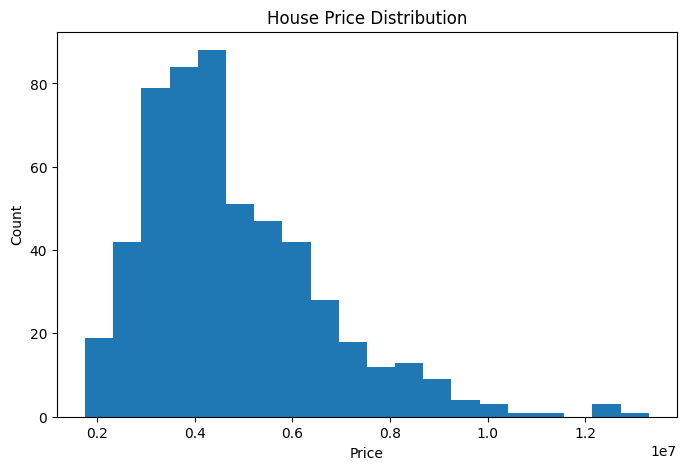

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df["price"], bins=20)
plt.title("House Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

In [12]:
df_corr = df.copy()

binary_cols = [
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'prefarea'
]

for col in binary_cols:
    df_corr[col] = df_corr[col].map({
        'yes': 1,
        'no': 0
    })

df_corr = pd.get_dummies(
    df_corr,
    columns=['furnishingstatus'],
    drop_first=True
)

df_corr.corr()["price"].sort_values(
    ascending=False
)

price                              1.000000
area                               0.535997
bathrooms                          0.517545
airconditioning                    0.452954
stories                            0.420712
parking                            0.384394
bedrooms                           0.366494
prefarea                           0.329777
mainroad                           0.296898
guestroom                          0.255517
basement                           0.187057
hotwaterheating                    0.093073
furnishingstatus_semi-furnished    0.063656
furnishingstatus_unfurnished      -0.280587
Name: price, dtype: float64

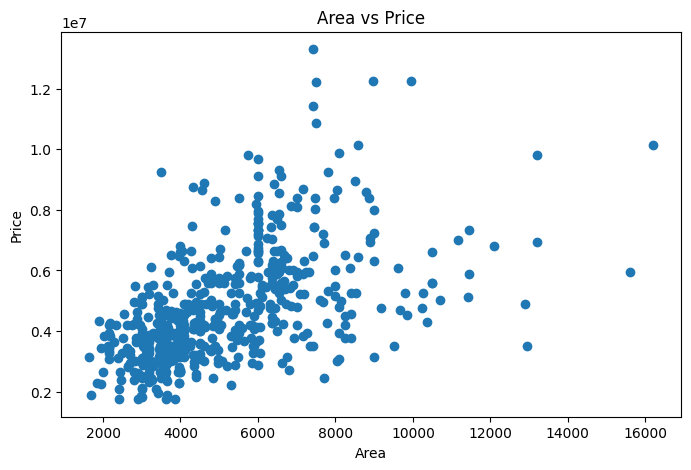

In [14]:
plt.figure(figsize=(8,5))
plt.scatter(df["area"], df["price"])
plt.title("Area vs Price")
plt.xlabel("Area")
plt.ylabel("Price")
plt.show()

## Key Insights

1. Area has a strong positive relationship with price.
2. Houses with more bathrooms tend to be more expensive.
3. Furnished properties generally have higher prices.
4. Air conditioning and preferred location increase property value.

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

# Load data
df = pd.read_csv("../data/housing.csv")

# Convert categorical columns
binary_cols = [
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'prefarea'
]

for col in binary_cols:
    df[col] = df[col].map({
        'yes': 1,
        'no': 0
    })

df = pd.get_dummies(
    df,
    columns=['furnishingstatus'],
    drop_first=True
)

# Features and target
X = df.drop("price", axis=1)
y = df["price"]

# Train model
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X, y)

# Feature Importance
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
0,area,0.466778
2,bathrooms,0.155097
9,parking,0.061611
3,stories,0.055559
8,airconditioning,0.054908
1,bedrooms,0.042395
12,furnishingstatus_unfurnished,0.039027
10,prefarea,0.034788
6,basement,0.030680
5,guestroom,0.018314


## Feature Importance Insights

Area is the most influential factor affecting house prices.

Properties with larger living areas tend to have significantly higher market values.

Bathrooms, parking availability, and air conditioning also contribute strongly to property valuation.

These insights can help buyers, sellers, and real estate professionals understand key drivers of housing prices.

In [20]:
import pandas as pd

df = pd.read_csv("../data/housing.csv")

df.head()


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


# Real Estate Data Analysis

## Dataset Overview

## Missing Values Check

## Summary Statistics

## Price Distribution

## Correlation Analysis

## Key Insights